In [3]:
from google.cloud import bigquery

# BigQuery 접속 객체 생성
bq = bigquery.Client(project="ping-v2-503916")

def cost(sql: str) -> float:
    """쿼리를 실행하지 않고 예상 스캔량만 확인한다."""

    cfg = bigquery.QueryJobConfig(
        dry_run=True,
        use_query_cache=False
    )

    job = bq.query(sql, job_config=cfg)
    bytes_processed = job.total_bytes_processed

    mib = bytes_processed / 2**20
    gib = bytes_processed / 2**30
    free_quota_ratio = gib / 1024 * 100

    print(f"예상 스캔량: {mib:,.3f} MiB")
    print(f"예상 스캔량: {gib:,.6f} GiB")
    print(f"월 1 TiB 무료 용량의 약 {free_quota_ratio:.8f}%")

    return gib

In [8]:
monthly_signup_sql = """
WITH monthly_signup AS (
  SELECT
    DATE_TRUNC(
      DATE(created_at, 'Asia/Seoul'),
      MONTH
    ) AS signup_month,
    COUNT(DISTINCT id) AS new_user_count
  FROM `ping-v2-503916.raw.app_user`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
  GROUP BY signup_month
),

monthly_with_previous AS (
  SELECT
    signup_month,
    new_user_count,
    LAG(new_user_count) OVER (
      ORDER BY signup_month
    ) AS previous_month_count
  FROM monthly_signup
)

SELECT
  signup_month,
  new_user_count,
  previous_month_count,
  new_user_count - previous_month_count AS increase_count,
  ROUND(
    SAFE_DIVIDE(
      new_user_count - previous_month_count,
      previous_month_count
    ) * 100,
    2
  ) AS growth_rate_percent
FROM monthly_with_previous
ORDER BY signup_month
"""

In [7]:
cost(monthly_signup_sql)

예상 스캔량: 0.439 MiB
예상 스캔량: 0.000429 GiB
월 1 TiB 무료 용량의 약 0.00004189%


0.0004289653152227402

In [10]:
# 월별 신규 가입자 수
df_monthly_signup = bq.query(monthly_signup_sql).to_dataframe()
df_monthly_signup

,signup_month,new_user_count,previous_month_count,increase_count,growth_rate_percent
0,2025-09-01,6976,<NA>,<NA>,NaN
1,2025-10-01,961,6976,-6015,-86.22
2,2025-11-01,945,961,-16,-1.66
3,2025-12-01,996,945,51,5.40
4,2026-01-01,525,996,-471,-47.29
5,2026-02-01,497,525,-28,-5.33
6,2026-03-01,4003,497,3506,705.43
7,2026-04-01,1477,4003,-2526,-63.10
8,2026-05-01,1562,1477,85,5.75
9,2026-06-01,1169,1562,-393,-25.16


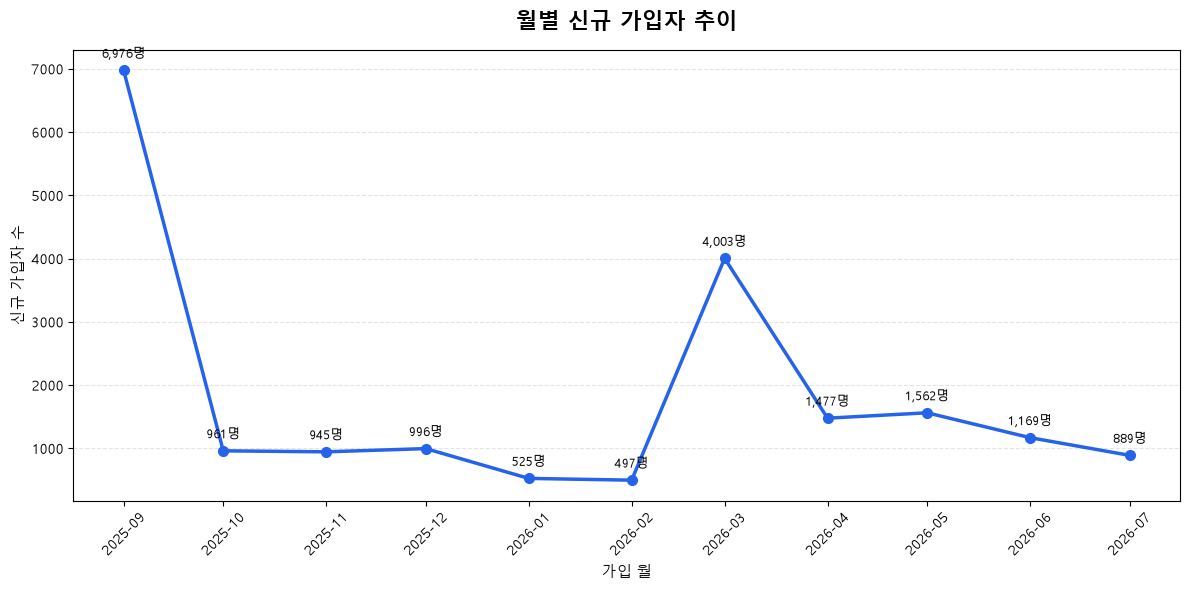

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 한글 폰트 설정: Windows
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 원본 데이터프레임을 보존하기 위해 복사
chart_df = df_monthly_signup.copy()

# 날짜 형식으로 변환하고 월 순서대로 정렬
chart_df["signup_month"] = pd.to_datetime(
    chart_df["signup_month"]
)

chart_df = chart_df.sort_values("signup_month")

# 그래프 크기
plt.figure(figsize=(12, 6))

# 선 그래프
plt.plot(
    chart_df["signup_month"],
    chart_df["new_user_count"],
    color="#2563EB",
    marker="o",
    markersize=7,
    linewidth=2.5
)

# 각 지점 위에 가입자 수 표시
for x, y in zip(
    chart_df["signup_month"],
    chart_df["new_user_count"]
):
    plt.annotate(
        f"{y:,}명",
        xy=(x, y),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

# X축을 연월 형식으로 표시
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.title(
    "월별 신규 가입자 추이",
    fontsize=16,
    fontweight="bold",
    pad=15
)
plt.xlabel("가입 월", fontsize=11)
plt.ylabel("신규 가입자 수", fontsize=11)

plt.xticks(rotation=45)
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)
plt.tight_layout()
plt.show()

In [12]:
grade_signup_sql = """
SELECT
  s.school_type,
  gc.grade,
  COUNT(DISTINCT u.id) AS user_count
FROM `ping-v2-503916.raw.app_user` AS u

JOIN `ping-v2-503916.raw.grade_class` AS gc
  ON u._source = gc._source
 AND u.class_id = gc.id
 AND gc._deleted_at IS NULL

JOIN `ping-v2-503916.raw.school` AS s
  ON gc._source = s._source
 AND gc.school_id = s.id
 AND s._deleted_at IS NULL

WHERE u._source = 'local'
  AND u._deleted_at IS NULL

GROUP BY
  s.school_type,
  gc.grade

ORDER BY
  s.school_type,
  gc.grade
"""

cost(grade_signup_sql)

예상 스캔량: 0.620 MiB
예상 스캔량: 0.000605 GiB
월 1 TiB 무료 용량의 약 0.00005911%


0.0006052423268556595

In [13]:
df_grade_signup = bq.query(
    grade_signup_sql
).to_dataframe()

df_grade_signup

,school_type,grade,user_count
0,HIGH,1,3852
1,HIGH,2,3860
2,HIGH,3,3816
3,MIDDLE,1,2820
4,MIDDLE,2,2822
5,MIDDLE,3,2830


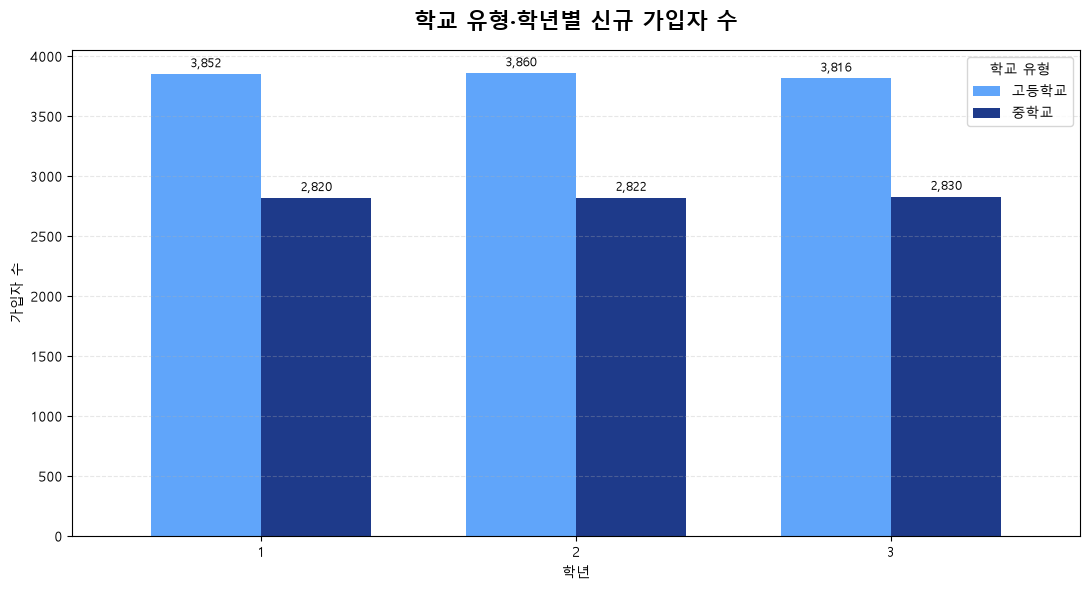

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

grade_chart = df_grade_signup.copy()

# 학교 유형명을 한글로 변경
grade_chart["school_type"] = grade_chart["school_type"].replace({
    "MIDDLE": "중학교",
    "HIGH": "고등학교",
    "M": "중학교",
    "H": "고등학교"
})

# 학년을 행, 학교 유형을 열로 변환
grade_pivot = grade_chart.pivot_table(
    index="grade",
    columns="school_type",
    values="user_count",
    aggfunc="sum",
    fill_value=0
)

ax = grade_pivot.plot(
    kind="bar",
    figsize=(11, 6),
    color=["#60A5FA", "#1E3A8A"],
    width=0.7
)

# 막대 위에 가입자 수 표시
for container in ax.containers:
    labels = [
        f"{bar.get_height():,.0f}"
        if bar.get_height() > 0 else ""
        for bar in container
    ]
    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=9
    )

plt.title(
    "학교 유형·학년별 신규 가입자 수",
    fontsize=16,
    fontweight="bold",
    pad=15
)
plt.xlabel("학년")
plt.ylabel("가입자 수")
plt.xticks(rotation=0)
plt.legend(title="학교 유형")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
region_signup_sql = """
SELECT
  r.sido,
  COUNT(DISTINCT u.id) AS user_count,
  COUNT(DISTINCT s.id) AS school_count,
  ROUND(
    SAFE_DIVIDE(
      COUNT(DISTINCT u.id),
      COUNT(DISTINCT s.id)
    ),
    2
  ) AS users_per_school
FROM `ping-v2-503916.raw.app_user` AS u

JOIN `ping-v2-503916.raw.grade_class` AS gc
  ON u._source = gc._source
 AND u.class_id = gc.id
 AND gc._deleted_at IS NULL

JOIN `ping-v2-503916.raw.school` AS s
  ON gc._source = s._source
 AND gc.school_id = s.id
 AND s._deleted_at IS NULL

JOIN `ping-v2-503916.raw.region` AS r
  ON s._source = r._source
 AND s.region_id = r.id
 AND r._deleted_at IS NULL

WHERE u._source = 'local'
  AND u._deleted_at IS NULL

GROUP BY r.sido
ORDER BY user_count DESC
"""

cost(region_signup_sql)

예상 스캔량: 0.625 MiB
예상 스캔량: 0.000610 GiB
월 1 TiB 무료 용량의 약 0.00005956%


0.0006098737940192223

In [16]:
df_region_signup = bq.query(
    region_signup_sql
).to_dataframe()

df_region_signup

,sido,user_count,school_count,users_per_school
0,부산광역시,4888,11,444.36
1,경기도,3752,9,416.89
2,전라남도,2836,4,709.00
3,대구광역시,2503,6,417.17
4,강원특별자치도,2481,5,496.20
5,경상남도,1540,3,513.33
6,서울특별시,1191,7,170.14
7,충청남도,628,3,209.33
8,인천광역시,117,1,117.00
9,경상북도,64,1,64.00


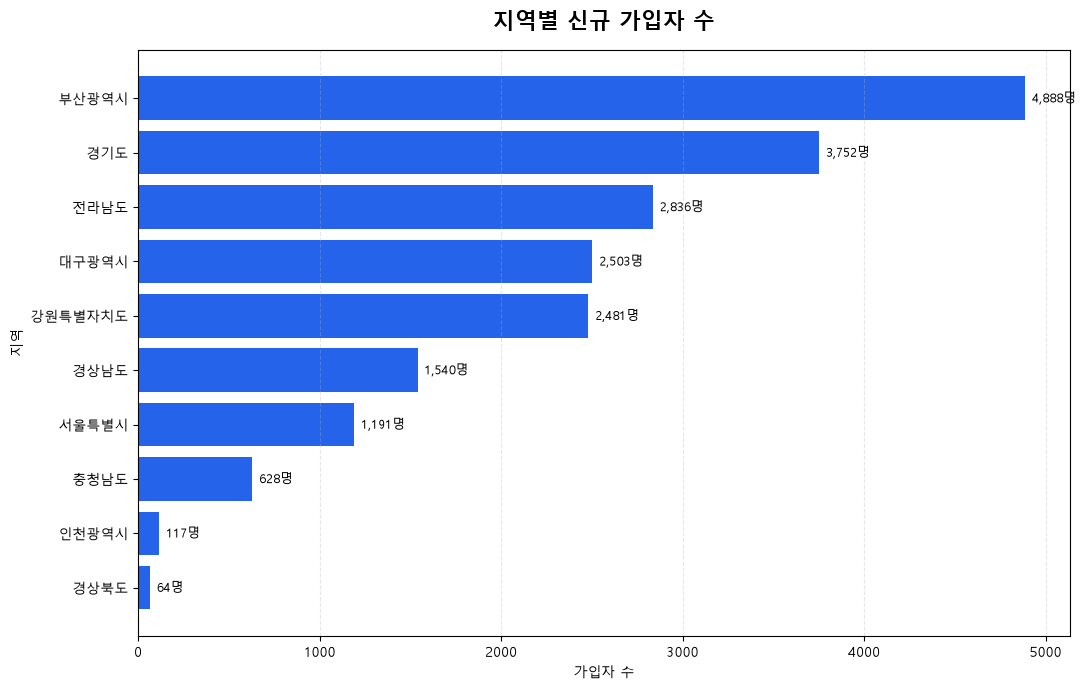

In [17]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

region_chart = (
    df_region_signup
    .sort_values("user_count", ascending=True)
    .copy()
)

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    region_chart["sido"],
    region_chart["user_count"],
    color="#2563EB"
)

# 막대 오른쪽에 가입자 수 표시
ax.bar_label(
    bars,
    labels=[
        f"{value:,.0f}명"
        for value in region_chart["user_count"]
    ],
    padding=5,
    fontsize=9
)

ax.set_title(
    "지역별 신규 가입자 수",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("가입자 수")
ax.set_ylabel("지역")
ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

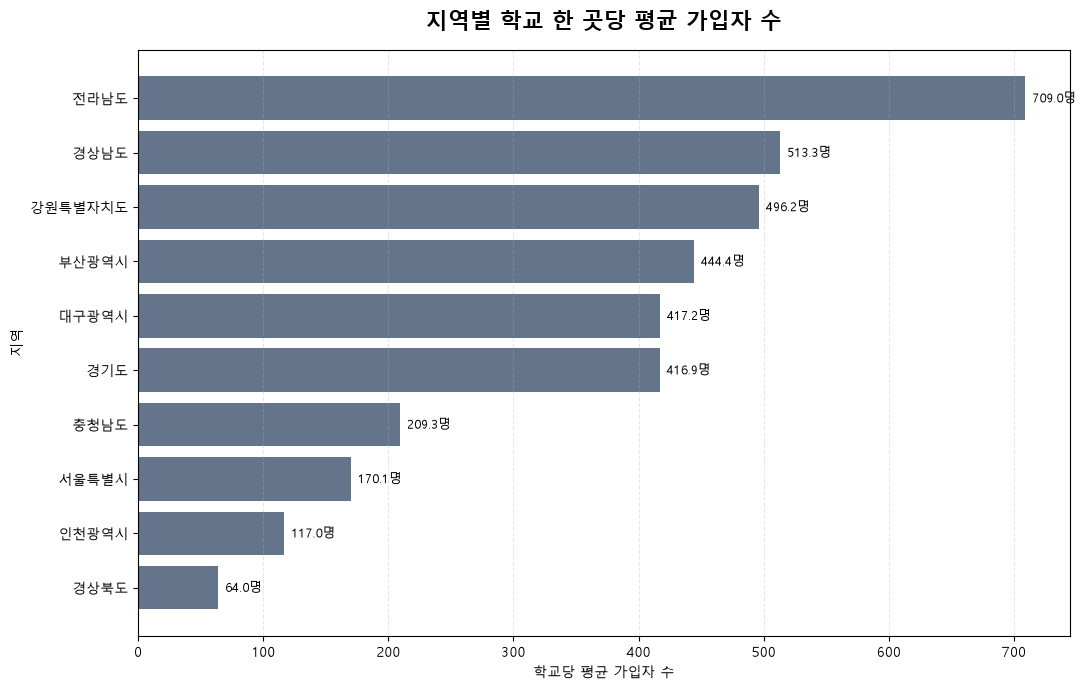

In [18]:
region_average = (
    df_region_signup
    .sort_values("users_per_school", ascending=True)
    .copy()
)

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    region_average["sido"],
    region_average["users_per_school"],
    color="#64748B"
)

ax.bar_label(
    bars,
    labels=[
        f"{value:,.1f}명"
        for value in region_average["users_per_school"]
    ],
    padding=5,
    fontsize=9
)

ax.set_title(
    "지역별 학교 한 곳당 평균 가입자 수",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("학교당 평균 가입자 수")
ax.set_ylabel("지역")
ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
gender_signup_sql = """
WITH gender_count AS (
  SELECT
    COALESCE(
      CAST(gender AS STRING),
      'UNKNOWN'
    ) AS gender,
    COUNT(DISTINCT id) AS user_count
  FROM `ping-v2-503916.raw.app_user`
  WHERE _source = 'local'
    AND _deleted_at IS NULL
  GROUP BY gender
)

SELECT
  gender,
  user_count,
  ROUND(
    SAFE_DIVIDE(
      user_count,
      SUM(user_count) OVER ()
    ) * 100,
    2
  ) AS user_share_percent
FROM gender_count
ORDER BY user_count DESC
"""

cost(gender_signup_sql)

예상 스캔량: 0.344 MiB
예상 스캔량: 0.000336 GiB
월 1 TiB 무료 용량의 약 0.00003279%


0.00033572595566511154

In [21]:
df_gender_signup = bq.query(
    gender_signup_sql
).to_dataframe()

df_gender_signup

,gender,user_count,user_share_percent
0,F,11792,58.96
1,M,8208,41.04


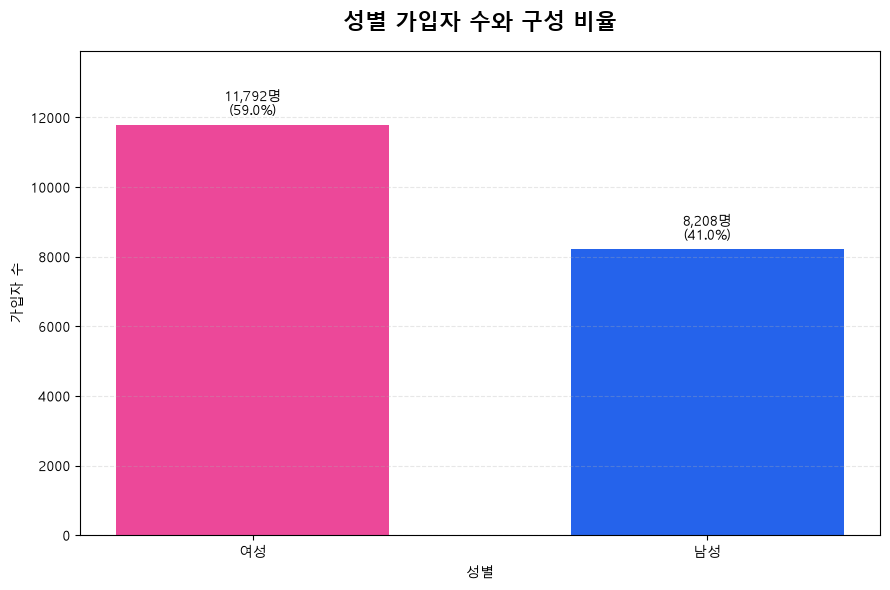

In [22]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

gender_chart = df_gender_signup.copy()

# 데이터에 저장된 성별 코드를 한글로 변경
gender_chart["gender_label"] = gender_chart["gender"].replace({
    "M": "남성",
    "MALE": "남성",
    "F": "여성",
    "FEMALE": "여성",
    "UNKNOWN": "미입력"
})

fig, ax = plt.subplots(figsize=(9, 6))

colors = {
    "남성": "#2563EB",
    "여성": "#EC4899",
    "미입력": "#94A3B8"
}

bar_colors = [
    colors.get(gender, "#64748B")
    for gender in gender_chart["gender_label"]
]

bars = ax.bar(
    gender_chart["gender_label"],
    gender_chart["user_count"],
    color=bar_colors,
    width=0.6
)

# 가입자 수와 비율 표시
labels = [
    f"{count:,.0f}명\n({ratio:.1f}%)"
    for count, ratio in zip(
        gender_chart["user_count"],
        gender_chart["user_share_percent"]
    )
]

ax.bar_label(
    bars,
    labels=labels,
    padding=5,
    fontsize=10
)

ax.set_title(
    "성별 가입자 수와 구성 비율",
    fontsize=16,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("성별")
ax.set_ylabel("가입자 수")
ax.grid(axis="y", linestyle="--", alpha=0.3)

# 막대 위 글자가 잘리지 않도록 공간 확보
ax.set_ylim(
    0,
    gender_chart["user_count"].max() * 1.18
)

plt.tight_layout()
plt.show()